### Libs

In [1]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Specify video path

In [2]:
# Define video path
video_path = Path.cwd().parent / "videos/input_sample/turnaround_video.mp4"

if not video_path.exists():
    raise FileNotFoundError(f"Video file not found at {video_path}")

### Read the first frame

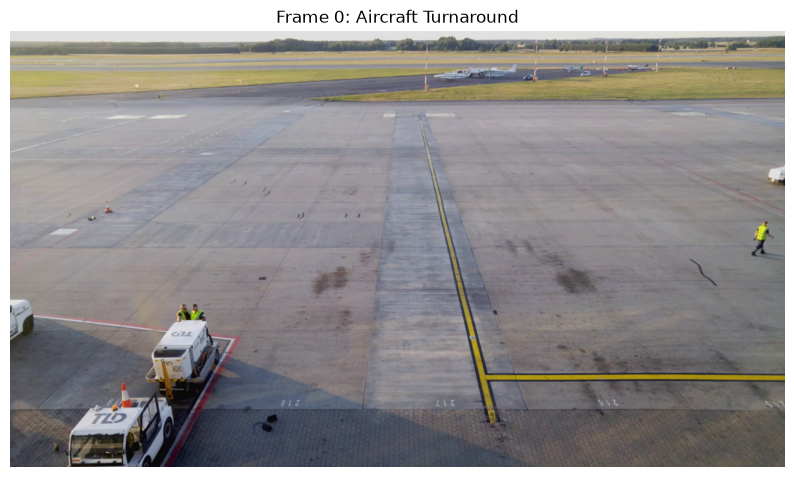

In [3]:
# Initialize the VideoCapture object (file pointer)
cap = cv2.VideoCapture(str(video_path))

# Extract first frame
success, frame_bgr = cap.read()

# Convert the frame from BGR (OpenCV's default) to RGB (Matplotlib's default)
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

# Display the frame using Matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.title("Frame 0: Aircraft Turnaround")
plt.axis('off')
plt.show()

cap.release()

### Sampling and slicing

In an aircraft turnaround scenario, events happen over minutes (e.g., the catering truck arriving, refueling, baggage loading). Analyzing every single frame at 30 or 60 Frames Per Second (FPS) is computationally wasteful and bad MLOps practice. Furthermore, the camera likely captures a lot of irrelevant background (the sky, the runway, neighboring gates). That's why we introduce sampling and slicing for temporal control and spatial focusing.

In [4]:
cap = cv2.VideoCapture(str(video_path))

# Read video metadata
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
duration_sec = total_frames / fps if fps > 0 else 0

print(f"Video stats: {total_frames} frames, {fps:.2f} FPS, {duration_sec:.2f} seconds")

cap.release()

Video stats: 2690 frames, 30.00 FPS, 89.67 seconds


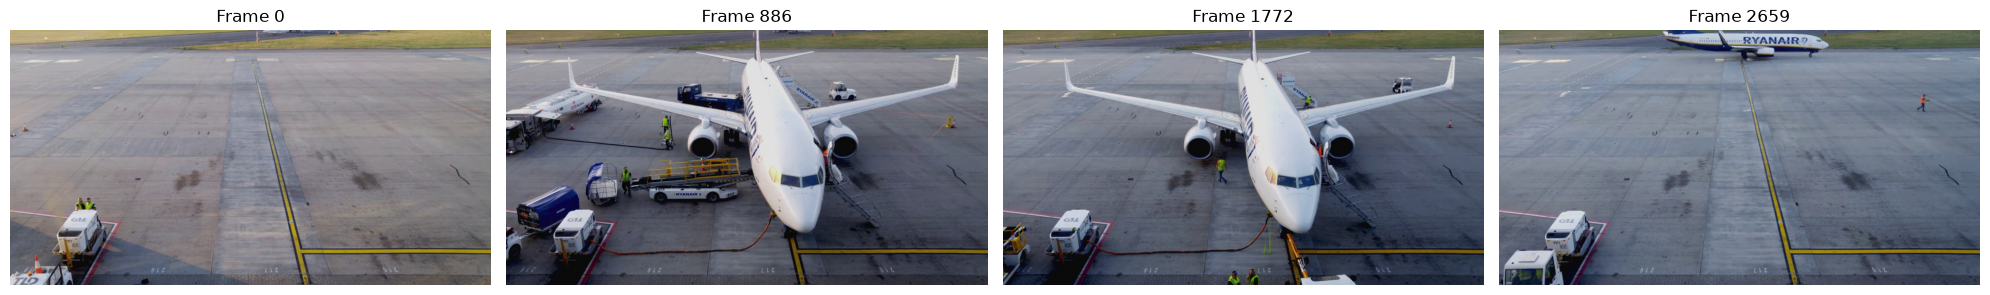

In [5]:
# Define a Region of Interest (ROI) - [y1:y2, x1:x2]
# For example, let's say we want to focus on a specific area of the frame where the aircraft is located.
cap = cv2.VideoCapture(str(video_path))

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # Reset to the first frame
_, test_frame = cap.read()
h, w, _ = test_frame.shape # height, width, channels

y1, y2 = int(h * 0.1), int(h * 0.9)
x1, x2 = int(w * 0.1), int(w * 0.95)

# Sample 4 evenly spaced frames from the video for visualization
num_samples = 4
# Back off by 30 frames to avoid corrupted tail-end metadata
safe_end_frame = max(0, total_frames - 30)
sample_indices = np.linspace(0, safe_end_frame - 1, num_samples, dtype=int)

fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))

for i, frame_idx in enumerate(sample_indices):
    # Move pointer to the specific frame index
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    success, frame_bgr = cap.read()

    if not success:
        print(f"Failed to read frame at index {frame_idx}")
        continue

    # Convert color space
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    # Crop the frame using ROI
    roi_frame = frame_rgb[y1:y2, x1:x2]

    # Display
    axes[i].imshow(roi_frame)
    axes[i].axis('off')
    axes[i].set_title(f"Frame {frame_idx}")

plt.tight_layout()
plt.show()

cap.release()

### Casting a wide net to detect objects

We will introduce PyTorch and Torchvision to run a pre-trained Faster R-CNN (Region-based Convolutional Neural Network) model over cropped frame. A foundational computer vision model used for object detection and localization. It identifies objects within an image and draws precise bounding boxes around them. Torchvision models are pre-trained on the COCO dataset, which conveniently includes classes highly relevant to a tarmac: "person" (ground crew), "truck" (catering/fuel trucks), and "car" (baggage tugs).

R-CNN approaches object detection as a two-stage process:
1. **Region Proposal**: It uses an algorithm like Selective Search to scan the image and extract approximately 2,000 overlapping candidate regions (Regions of Interest, or RoIs) that likely contain objects.
2. **Feature Extraction & Classification**: Each proposed region is warped into a fixed size and passed through a pre-trained Convolutional Neural Network (CNN). The features extracted are then fed into:
    - Support Vector Machines (SVMs): To classify the object.
    - Bounding Box Regressors: To finely adjust the coordinates and size of the bounding box.
3. **Non-Maximum Suppression (NMS)**: The model removes redundant or overlapping boxes, keeping only the most confident detections.

In [6]:
import torch
import torchvision.transforms.functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_bounding_boxes

In [7]:
# Device setup to use GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


In [8]:
# Load the Model and Weights
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights).to(device)

model.eval()  # Set model to evaluation mode to disable training-specific layers like dropout or batchnorm

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [9]:
# Prepare the Tensor
# Grab one of the cropped frames (e.g. roi_frame for testing)
# F.to_tensor converts (H, W, C) array to (C, H, W) tensor and normalizes pixel values to [0, 1]
input_tensor = F.to_tensor(roi_frame).to(device)

In [10]:
# Forward Pass with disabled gradient calculation for inference
with torch.no_grad():
    predictions = model([input_tensor])[0]  # Model expects a list of tensors, we take the first output

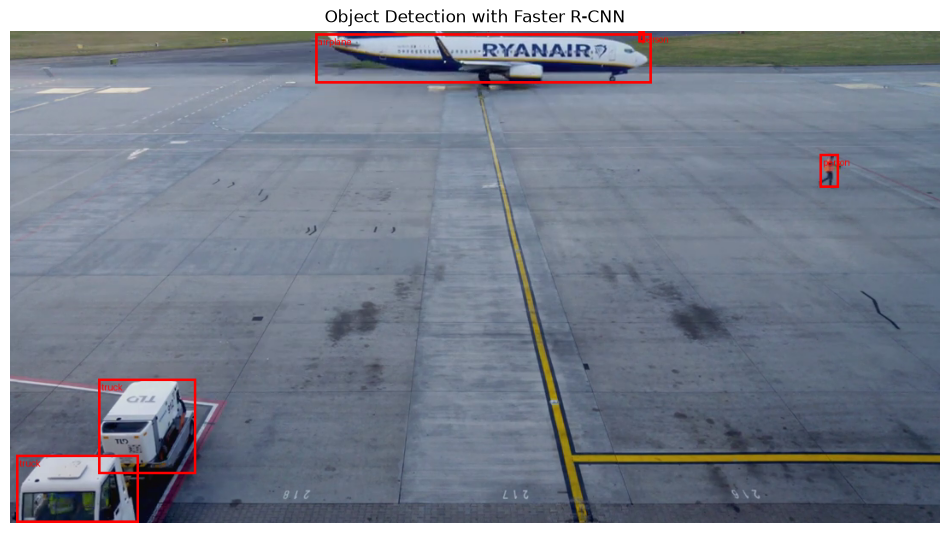

In [11]:
# Filter and visualize predictions with a confidence threshold
confidence_threshold = 0.7
COCO_CLASSES = weights.meta["categories"]  # Get class names from weights metadata

# Extract the data back to the CPU for visualization
# boxes: bounding box coordinates for the N detected objects
# labels: class indices for the N detected objects
# scores: confidence scores for the N detected objects
boxes = predictions['boxes'].cpu()
labels = predictions['labels'].cpu()
scores = predictions['scores'].cpu()

# Filter out low-confidence detections
high_conf_indices = scores > confidence_threshold
filtered_boxes = boxes[high_conf_indices]
filtered_labels = [COCO_CLASSES[label.item()] for label in labels[high_conf_indices]]

# Draw the boxes: draw_bounding_boxes requires uint8 tensor with shape (C, H, W) and pixel values in [0, 255]
uint8_tensor = torch.from_numpy(roi_frame).permute(2, 0, 1)
output_img_tensor = draw_bounding_boxes(
    uint8_tensor,
    boxes=filtered_boxes,
    labels=filtered_labels,
    colors="red",
    width=3
)

# Render back to matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(output_img_tensor.permute(1, 2, 0).numpy()) # Permute back to (H, W, C) for display
plt.title("Object Detection with Faster R-CNN")
plt.axis('off')
plt.show()

### Mechanics of Temporal Association

To track an object without relying on heavy visual re-identification models (which consume massive VRAM), we rely on spatial geometry and frame rates. Since videos run at roughly 30 frames per second, a vehicle will only move a few pixels between Frame $t$ and Frame $t+1$.

Therefore, we can associate objects across time by calculating the overlap of their bounding boxes. This is measured using the Jaccard Index, commonly known as Intersection over Union (IoU):

$$\text{IoU} = \frac{\text{Area of Intersection}}{\text{Area of Union}}$$

If the IoU between a box in Frame 1 and a box in Frame 2 exceeds a certain threshold, the tracking logic declares them the same object and carries the unique ID forward.

Typically, a Hungarian algorithm (`scipy.optimize.linear_sum_assignment`) is used to perfectly resolve tracking conflicts. However, for learning purposes we will build a "greedy" matching tracker in pure NumPy.

In [12]:
# Core Geometric Math
def compute_iou(boxA, boxB):
    # Extract coordinates
    xA = max(boxA[0], boxB[0]) # xA is the maximum of the left x-coordinates of both boxes
    yA = max(boxA[1], boxB[1]) # yA is the maximum of the top y-coordinates of both boxes
    xB = min(boxA[2], boxB[2]) # xB is the minimum of the right x-coordinates of both boxes
    yB = min(boxA[3], boxB[3]) # yB is the minimum of the bottom y-coordinates of both boxes

    # Calculate intersection area
    inter_width = max(0, xB - xA)
    inter_height = max(0, yB - yA)
    inter_area = inter_width * inter_height

    if inter_area == 0:
        return 0.0  # No overlap

    # Calculate union
    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union_area = boxA_area + boxB_area - inter_area

    # Compute IoU
    iou = inter_area / union_area
    return iou

# Stateful Tracker Architecture
class GreedyIoUTracker:
    """A simple IoU-based tracker that maintains object identities across frames."""
    def __init__(self, iou_threshold=0.3, max_lost_frames=5):
        """Initialize the tracker with IoU threshold and maximum lost frames."""
        self.tracks = [] # will hold dicts: {'id': int, 'box': list, 'class': str, 'lost_frames': int}
        self.next_id = 1
        self.iou_threshold = iou_threshold

        self.max_lost = max_lost_frames # Crucial for occlusions: If a worker walks behind a truck, we wait N frames before deleting their ID

    def update(self, new_boxes, new_classes):
        """
        Update the tracker with new detections. This method attempts to match existing tracks to new detections based on IoU.
        """
        updated_tracks = []
        matched_new_boxes = set()

        # Phase A: Attempt to match existing tracks to new detections based on IoU
        for track in self.tracks:
            best_iou = 0
            best_match_idx = -1

            for i, box in enumerate(new_boxes):
                if i in matched_new_boxes:
                    continue  # Skip already matched boxes

                iou = compute_iou(track['box'], box)
                if iou > best_iou:
                    best_iou = iou
                    best_match_idx = i

            if best_iou > self.iou_threshold:
                # SUCCESS: Track maintained, update coordinates and reset lost frame count
                track['box'] = new_boxes[best_match_idx]
                track['lost_frames'] = 0
                updated_tracks.append(track)
                matched_new_boxes.add(best_match_idx)
            else:
                # FAILURE: Track lost, increment lost frame count
                track['lost_frames'] += 1
                if track['lost_frames'] <= self.max_lost:
                    updated_tracks.append(track)  # Keep the track for now in case it reappears

        # Phase B: Register unmatched detections as new tracks
        for i, box in enumerate(new_boxes):
            if i not in matched_new_boxes:
                new_track = {
                    'id': self.next_id,
                    'box': box,
                    'class': new_classes[i],
                    'lost_frames': 0
                }
                updated_tracks.append(new_track)
                self.next_id += 1

        self.tracks = updated_tracks
        return self.tracks

In [14]:
from tqdm import tqdm

# Reset video pointer to the first frame for tracking
cap = cv2.VideoCapture(str(video_path))

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # Reset to the first frame
_, test_frame = cap.read()
h, w, _ = test_frame.shape # height, width, channels

y1, y2 = int(h * 0.1), int(h * 0.9)
x1, x2 = int(w * 0.1), int(w * 0.95)

# Initialize the tracker with a reasonable IoU threshold and max lost frames
tracker = GreedyIoUTracker(iou_threshold=0.3, max_lost_frames=5)
COCO_CLASSES = weights.meta["categories"]  # Get class names from weights metadata

# Initialize event Log
event_log = []  # List to hold events like 'arrival', 'departure', etc.

# Reset video pointer
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # Start from the first frame
max_frames_to_process = 1000  # Limit for testing purposes

print("Starting video processing and tracking...")
for frame_idx in tqdm(range(max_frames_to_process)):
    success, frame_bgr = cap.read()
    if not success:
        print(f"End of video or read error at frame {frame_idx}. Stopping processing.")
        break  # End of video or read error

    # Crop to ROI and convert to RGB
    ri_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)[y1:y2, x1:x2]

    # Run detection model
    input_tensor = F.to_tensor(ri_rgb).to(device)
    with torch.no_grad():
        predictions = model([input_tensor])[0]

    # Filter predictions based on confidence threshold
    keep_idx = predictions["scores"].cpu() > confidence_threshold
    boxes = predictions["boxes"].cpu()[keep_idx].numpy()
    labels = [COCO_CLASSES[label.item()] for label in predictions["labels"].cpu()[keep_idx]]

    # Update tracker with current frame's detections
    active_tracks = tracker.update(boxes, labels)

    # Log the state to our operational event log
    for track in active_tracks:
        if track["lost_frames"] == 0:  # Only log active tracks
            event_log.append({
                "frame_idx": frame_idx,
                "track_id": track["id"],
                "object_class": track["class"],
                "x_min": track["box"][0],
                "y_min": track["box"][1],
                "x_max": track["box"][2],
                "y_max": track["box"][3]
            })

# Convert to pd DataFrame
df_turnaround_log = pd.DataFrame(event_log)    
print(f"Processed {len(df_turnaround_log)} tracking events over {max_frames_to_process} frames.")
display(df_turnaround_log.head())

Starting video processing and tracking...


100%|██████████| 1000/1000 [01:40<00:00, 10.00it/s]

Processed 15820 tracking events over 1000 frames.


,frame_idx,track_id,object_class,x_min,y_min,x_max,y_max
0,0,1,person,168.523102,377.509308,194.063080,406.682861
1,0,2,person,147.667770,378.031982,171.162033,407.446136
2,0,3,truck,99.635368,405.869843,223.901154,532.732178
3,1,1,person,168.523102,377.509308,194.063080,406.682861
4,1,2,person,147.667770,378.031982,171.162033,407.446136


### Extracting impact metrics

Airlines only make money when planes are in the air. Ground turnaround time is a massive cost center. If we can prove exactly how long the catering truck, baggage loaders, or fuel trucks spent attached to the aircraft, we have a direct measurement of ground efficiency.

#### Time-in-Zone Metric

Since our pre-trained Faster R-CNN model tracks COCO classes, it likely classified the catering, fuel, and baggage vehicles generically as "truck". We can group our dataframe by track_id to find out exactly how long each vehicle was present in the frame.

In [15]:
# Filter the log events for vehicles
vehicles_df = df_turnaround_log[df_turnaround_log["object_class"].isin(["car", "truck", "bus"])]

if vehicles_df.empty:
    print("No vehicle events detected in the log.")
else:
    # Calculate entry and exit frames for each unique vehicle track
    service_times = vehicles_df.groupby(["track_id", "object_class"])["frame_idx"]\
        .agg(['min', 'max']).reset_index()

    # Convert frame counts into time in seconds
    service_times["duration_seconds"] = (service_times["max"] - service_times["min"]) / fps
    service_times["duration_minutes"] = (service_times["duration_seconds"] / 60).round(2)

    # Filter out brief false positives (e.g. truck that was only tracked for 1-2 seconds)
    valid_service = service_times[service_times["duration_seconds"] >= 5]

    valid_service = valid_service.sort_values(by="duration_seconds", ascending=False)
    print("Vehicle Service Times (Filtered for Valid Durations):")
    display(valid_service) 

Vehicle Service Times (Filtered for Valid Durations):


,track_id,object_class,min,max,duration_seconds,duration_minutes
44,249,truck,222,999,25.900000,0.43
0,3,truck,0,586,19.533333,0.33
79,694,truck,364,750,12.866667,0.21
111,1599,truck,564,891,10.900000,0.18
139,2086,truck,709,999,9.666667,0.16
149,2163,truck,757,999,8.066667,0.13
81,724,truck,372,601,7.633333,0.13
42,247,bus,220,374,5.133333,0.09


#### Process Sequencing

Once we know how long things take, the next question is in what order did they happen. Did the ground crew ( "person") arrive to inspect the engine before or after the baggage train ("car") arrived?

In [16]:
# Find out when each class of object first appeared on the screen
timeline = df_turnaround_log.groupby("object_class")["frame_idx"].min().sort_values()

# Convert frames to timestamps
timeline_seconds = timeline / fps

print("Timeline of First Appearances (in seconds):")
for obj_class, time_sec in timeline_seconds.items():
    print(f"- {obj_class.capitalize()} arrived at {time_sec:.1f} seconds")

Timeline of First Appearances (in seconds):
- Person arrived at 0.0 seconds
- Truck arrived at 0.0 seconds
- Car arrived at 0.5 seconds
- Backpack arrived at 0.9 seconds
- Skateboard arrived at 0.9 seconds
- Airplane arrived at 1.3 seconds
- Bird arrived at 3.2 seconds
- Handbag arrived at 3.9 seconds
- Bus arrived at 5.0 seconds
- Motorcycle arrived at 8.8 seconds
- Skis arrived at 9.4 seconds
- Dog arrived at 10.7 seconds
- Kite arrived at 12.4 seconds
- Bicycle arrived at 12.5 seconds
- Suitcase arrived at 13.5 seconds
- Chair arrived at 15.8 seconds
- Potted plant arrived at 18.3 seconds
- Surfboard arrived at 19.7 seconds
- Snowboard arrived at 20.6 seconds
- Boat arrived at 29.9 seconds


### Full Video Rendering Pipeline

In [ ]:
from tqdm import tqdm

# Ensure device and model are loaded, and model.eval() is set
# Define your paths
video_path = Path.cwd().parent / "videos/input_sample/turnaround_video.mp4"
output_path = Path.cwd().parent / "videos/annotated/turnaround_annotated.mp4"

cap = cv2.VideoCapture(str(video_path))
fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0: fps = 30 # Fallback in case metadata is missing

# 1. Setup the Video Writer
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec for .mp4
out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

# 2. Reset Tracker and State Logging
tracker = GreedyIoUTracker(iou_threshold=0.3, max_lost_frames=5)
first_seen = {} # Dictionary to store: {track_id: frame_idx_when_first_seen}

# Using the ROI limits defined in Step 2 (adjust these to your video)
y1, y2 = int(height * 0.2), int(height * 0.9)
x1, x2 = int(width * 0.1), int(width * 0.9)

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) - 30 # Back off by 30 frames to avoid corrupted tail-end metadata

print(f"Rendering annotated video to {output_path}...")

for frame_idx in tqdm(range(total_frames)):
    success, frame_bgr = cap.read()
    if not success:
        break
        
    # Crop to ROI and run inference
    roi_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)[y1:y2, x1:x2]
    input_tensor = F.to_tensor(roi_rgb).to(device)
    
    with torch.no_grad():
        predictions = model([input_tensor])[0]
        
    # Filter predictions
    keep_idx = predictions['scores'].cpu() > 0.7
    boxes = predictions['boxes'].cpu()[keep_idx].numpy()
    labels = [COCO_CLASSES[label.item()] for label in predictions['labels'].cpu()[keep_idx]]
    
    # Update Tracker
    active_tracks = tracker.update(boxes, labels)
    
    # 3. Annotate the Original Frame
    for track in active_tracks:
        if track['lost_frames'] == 0: # Only draw if actively visible
            track_id = track['id']
            
            # Record birth frame if this is a new object
            if track_id not in first_seen:
                first_seen[track_id] = frame_idx
                
            # Calculate duration alive in seconds
            duration_sec = (frame_idx - first_seen[track_id]) / fps
            
            # Shift ROI box coordinates back to global frame coordinates
            box = track['box']
            global_xmin = int(box[0]) + x1
            global_ymin = int(box[1]) + y1
            global_xmax = int(box[2]) + x1
            global_ymax = int(box[3]) + y1
            
            # Formulate the label: "Truck #5 | 12.5s"
            label_text = f"{track['class'].capitalize()} #{track_id} | {duration_sec:.1f}s"
            
            # Draw Bounding Box (Color is BGR: Green)
            cv2.rectangle(frame_bgr, (global_xmin, global_ymin), (global_xmax, global_ymax), (0, 255, 0), 2)
            
            # Draw Text Background (for readability)
            (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(frame_bgr, (global_xmin, global_ymin - 25), (global_xmin + text_w, global_ymin), (0, 255, 0), -1)
            
            # Draw Text (Color is BGR: Black)
            cv2.putText(frame_bgr, label_text, (global_xmin, global_ymin - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    # 4. Write the fully annotated frame to the new video file
    out.write(frame_bgr)

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()
print("Video rendering complete!")

Rendering annotated video to c:\Users\szpws\GIT\aircraft-turnaround-tracker\videos\turnaround_annotated.mp4...


  0%|          | 0/2660 [00:00<?, ?it/s]

100%|██████████| 2660/2660 [05:47<00:00,  7.65it/s]

Video rendering complete!


# Data Ingestion through YouTube

In [13]:
def run_inference_on_video(
        frame_bgr: np.ndarray,
        frame_idx: int,
        tracker: GreedyIoUTracker,
        first_seen: dict,
        fps: float,
        device: torch.device,
        model: torch.nn.Module,
        COCO_CLASSES: list,
        x1: int,
        y1: int,
        x2: int,
        y2: int) -> tuple[np.ndarray, GreedyIoUTracker, dict]:
    """
    Run inference on a single video frame, update the tracker, and annotate the frame with bounding boxes and labels.
    
    Args:
        frame_bgr (np.ndarray): The current video frame in BGR format.
        frame_idx (int): The index of the current frame in the video.
        tracker (GreedyIoUTracker): The object tracker instance.
        first_seen (dict): Dictionary to track the first frame index when each object was seen.
        fps (float): Frames per second of the video.
        device (torch.device): The device (CPU or GPU) to run the model on.
        model (torch.nn.Module): The object detection model.
        COCO_CLASSES (list): List of class names corresponding to the model's output labels.
        x1, y1, x2, y2 (int): Coordinates defining the Region of Interest (ROI) in the frame.

    Returns:
        frame_bgr (np.ndarray): The annotated video frame with bounding boxes and labels.
        tracker (GreedyIoUTracker): The updated tracker instance after processing the current frame.
        first_seen (dict): Updated dictionary tracking the first frame index when each object was seen.
    """
    # Crop to ROI and run inference
    roi_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)[y1:y2, x1:x2]
    input_tensor = F.to_tensor(roi_rgb).to(device)
    
    with torch.no_grad():
        predictions = model([input_tensor])[0]
        
    # Filter predictions
    keep_idx = predictions['scores'].cpu() > 0.7
    boxes = predictions['boxes'].cpu()[keep_idx].numpy()
    labels = [COCO_CLASSES[label.item()] for label in predictions['labels'].cpu()[keep_idx]]
    
    # Update Tracker
    active_tracks = tracker.update(boxes, labels)
    
    # 3. Annotate the Original Frame
    for track in active_tracks:
        if track['lost_frames'] == 0: # Only draw if actively visible
            track_id = track['id']
            
            # Record birth frame if this is a new object
            if track_id not in first_seen:
                first_seen[track_id] = frame_idx
                
            # Calculate duration alive in seconds
            duration_sec = (frame_idx - first_seen[track_id]) / fps
            
            # Shift ROI box coordinates back to global frame coordinates
            box = track['box']
            global_xmin = int(box[0]) + x1
            global_ymin = int(box[1]) + y1
            global_xmax = int(box[2]) + x1
            global_ymax = int(box[3]) + y1
            
            # Formulate the label: "Truck #5 | 12.5s"
            label_text = f"{track['class'].capitalize()} #{track_id} | {duration_sec:.1f}s"
            
            # Draw Bounding Box (Color is BGR: Green)
            cv2.rectangle(frame_bgr, (global_xmin, global_ymin), (global_xmax, global_ymax), (0, 255, 0), 2)
            
            # Draw Text Background (for readability)
            (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(frame_bgr, (global_xmin, global_ymin - 25), (global_xmin + text_w, global_ymin), (0, 255, 0), -1)
            
            # Draw Text (Color is BGR: Black)
            cv2.putText(frame_bgr, label_text, (global_xmin, global_ymin - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    return frame_bgr, tracker, first_seen

In [23]:
import yt_dlp
import time

# yt_url = "https://www.youtube.com/watch?v=J__OIvAZGUo"
yt_url = "https://www.youtube.com/watch?v=yKTvu_T7eOc"

# Ask yt-dlp to find the raw streaml URL for the video
ydl_opts = {
    "format": "best[ext=mp4]/",
    "quiet": True,
    "noplaylist": True
}

print(f"Fetching video info for {yt_url}...")
with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    info_dict = ydl.extract_info(yt_url, download=False)

    stream_url = info_dict["url"]
    title = info_dict.get("title", "Unknown Title")

print(f"Successfully fetched stream URL for '{title}'")
print("Connecting openCV VideoCapture to the stream URL...")

clean_title = "".join(c if c.isalnum() else "_" for c in title)
output_path = Path.cwd().parent / f"videos/annotated/{clean_title}.mp4"
output_path.parent.mkdir(parents=True, exist_ok=True)
print(f"Will save annotated video to: {output_path}")

# Feed the URL to OpenCV which will recognize HTTP/HTTPS URLs and treat them as network stream
cap = cv2.VideoCapture(stream_url)
if not cap.isOpened():
    raise RuntimeError("Failed to open video stream. Check the URL or your internet connection.")
fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0 or fps != fps:
    fps = 30  # Fallback in case metadata is missing or NaN

# Reset Tracker and State Logging
tracker = GreedyIoUTracker(iou_threshold=0.3, max_lost_frames=5)
first_seen = {} # Dictionary to store: {track_id: frame_idx_when_first_seen}

# We will initialize the VideoWriter inside the loop to guarantee perfect dimensions
out = None 
x1, y1, x2, y2 = 0, 0, 0, 0 # Will set dynamically

print(f"Video stream opened successfully. FPS: {fps:.2f}")
# Guardrail, limit by frames to avoid long processing times
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) - 30 # Back off by 30 frames to avoid corrupted tail-end metadata
max_frames_to_process = min(int(120 * fps), total_frames)  # Process up to 2 minutes of video or the total number of frames
frame_count = 0

start_time = time.time()
while frame_count < max_frames_to_process:
    success, frame = cap.read()
    if not success:
        print("End of stream or read error. Stopping processing.")
        break

    if out is None:
        height, width = frame.shape[:2]
        fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
        out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

        if not out.isOpened():
            raise RuntimeError("Failed to open VideoWriter. Check the output path and codec.")
        
        # Setup ROI based on actual frame dimensions
        y1, y2 = int(height * 0.2), int(height * 0.9)
        x1, x2 = int(width * 0.1), int(width * 0.9)

    frame_bgr, tracker, first_seen = run_inference_on_video(
        frame_bgr=frame,
        frame_idx=frame_count,
        tracker=tracker,
        first_seen=first_seen,
        fps=fps,
        device=device,
        model=model,
        COCO_CLASSES=COCO_CLASSES,
        x1=x1,
        y1=y1,
        x2=x2,
        y2=y2
    )

    out.write(frame_bgr)

    if frame_count % int(fps) == 0:  # Log every second
        elapsed_time = time.time() - start_time
        print(f"Processed {frame_count} frames in {elapsed_time:.2f} seconds.")

    frame_count += 1

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()
print("Video rendering complete!")


Fetching video info for https://www.youtube.com/watch?v=yKTvu_T7eOc...


Successfully fetched stream URL for 'Time-Lapse of aircraft: Ground Services for Pegasus Airlines A320 with Sunset'
Connecting openCV VideoCapture to the stream URL...
Will save annotated video to: c:\Users\szpws\GIT\aircraft-turnaround-tracker\videos\annotated\Time_Lapse_of_aircraft__Ground_Services_for_Pegasus_Airlines_A320_with_Sunset.mp4
Video stream opened successfully. FPS: 30.00
Processed 0 frames in 0.37 seconds.
Processed 30 frames in 3.17 seconds.
Processed 60 frames in 6.10 seconds.
Processed 90 frames in 9.69 seconds.
Processed 120 frames in 13.29 seconds.
Processed 150 frames in 16.90 seconds.
Processed 180 frames in 20.77 seconds.
Processed 210 frames in 24.60 seconds.
Processed 240 frames in 28.31 seconds.
End of stream or read error. Stopping processing.
Video rendering complete!
